1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 1


1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 2


=====Library stat =====
Total Transactions: 20
Most Borrowed Book: The Alchemist
Average Borrowing time: 17.8
Busiest Day: Wednesday
1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 3
Enter Genre:  Science


Filtered
  Transaction ID       Date User ID               Book Title    Genre  \
4         TXN005 2024-01-11  USR105  A Brief History of Time  Science   

   Borrowing Duration (Days)  
4                         30  
1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 4


===Generates reports===
                 User ID  Borrowing Duration (Days)
Genre                                              
Biography              1                  25.000000
Business               1                  14.000000
Classic                3                  12.333333
Dystopian              1                  12.000000
Fantasy                2                  12.500000
Fiction                1                  14.000000
Finance                1                  21.000000
Mystery                1                  18.000000
Non-Fiction            1                  21.000000
Psychology             1                  20.000000
Science                1                  30.000000
Science Fiction        2                  15.500000
Self-Help              2                  29.000000
Thriller               2                  15.000000
1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 5


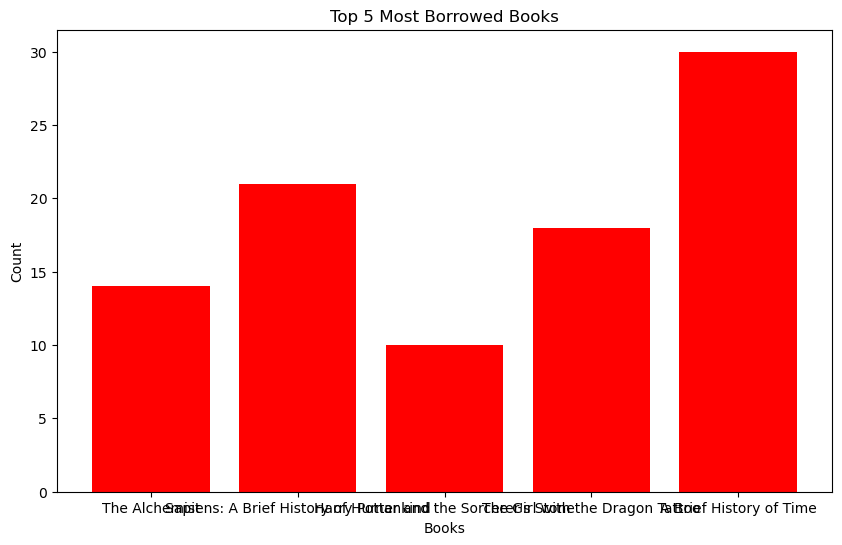

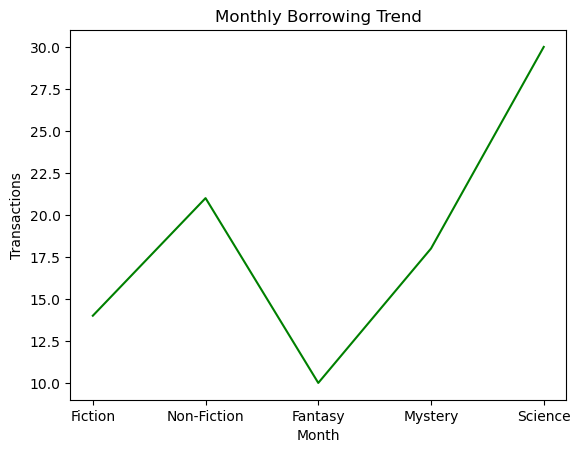

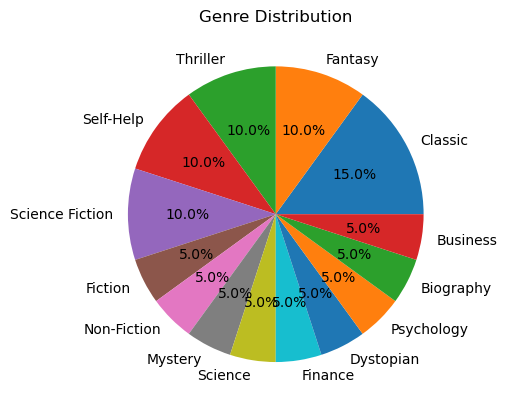

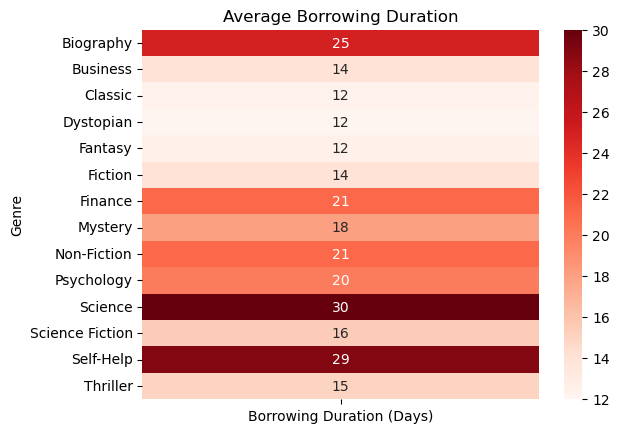

1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


Enter your choice : 6


Thank you
1.load_dataset
2.calculates_stat
3.filter_transations
4.generate_report
5.create_visualizations
6.Thank you


In [ ]:
# Project: "E LIBRARY DATA INSIGHTS DESHBOARD"


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class LibraryData:

    def __init__(self):
        self.df = None

    def load_dataset(self,file_path):
        try:
            self.df = pd.read_csv(file_path)

            required_col = ["Transaction ID",
                "Date",
                "User ID",
                "Book Title",
                "Genre",
                "Borrowing Duration (Days)"]

            for col in required_col:
                if col not in self.df.columns:
                    print(f"Missing columns: {col}")
                    return False

            # Remove missing value

            self.df.dropna(inplace=True)

            # Remove duplicate data

            self.df.drop_duplicates(inplace=True)

            # convert date columns

            self.df["Date"]=pd.to_datetime(self.df["Date"])

        except Exception as e:
            print("Error:",e)
            return False

    def calculates_stat(self):
        print("=====Library stat =====")

        total_transactions = len(self.df)

        most_borrowed_book = self.df["Book Title"].value_counts().idxmax()

        avg_time = np.mean(self.df["Borrowing Duration (Days)"])

        busiest_day = self.df["Date"].dt.day_name().value_counts().idxmax()

        print("Total Transactions:", total_transactions)
        print("Most Borrowed Book:", most_borrowed_book)
        print("Average Borrowing time:", round(avg_time, 2))
        print("Busiest Day:", busiest_day)

    def filter_transations(self,genre):

        filtered = self.df[self.df["Genre"] == genre]

        if len(filtered)== 0:
            print("No Record Found")
        else:
            print("Filtered")
            print(filtered)

    def generate_report(self):
        report = self.df.groupby("Genre").agg({"User ID":"count","Borrowing Duration (Days)":"mean"})
        print("===Generates reports===")
        print(report)

    def create_visualizations(self):
        # bar chart

        top = self.df.head(5)
        plt.figure(figsize=(10,6))
        plt.bar(top["Book Title"],top["Borrowing Duration (Days)"],color="red")
        plt.title("Top 5 Most Borrowed Books")
        plt.xlabel("Books")
        plt.ylabel("Count")
        plt.show()

        # line chart

        plt.plot(top["Genre"],top["Borrowing Duration (Days)"],color="green")
        plt.title("Monthly Borrowing Trend")
        plt.xlabel("Month")
        plt.ylabel("Transactions")
        plt.show()


        # Pie chart

        data = self.df["Genre"].value_counts()
        plt.pie(data,labels=data.index,autopct="%1.1f%%")
        plt.title("Genre Distribution")
        plt.show()

        # heatmap

        heatmap_data = self.df.pivot_table(
            index="Genre",
            values="Borrowing Duration (Days)",
            aggfunc="mean")

        sns.heatmap(heatmap_data,annot=True,cmap="Reds")
        plt.title("Average Borrowing Duration")
        plt.show()


# Main program

def main():    
    d = LibraryData()

    while True:
        print("1.load_dataset")
        print("2.calculates_stat")
        print("3.filter_transations")
        print("4.generate_report")
        print("5.create_visualizations")
        print("6.Thank you")

        choice = input("Enter your choice :")

        if choice == "1":
            
            d.load_dataset("library_transitions.csv")

        elif choice == "2":
            d.calculates_stat()

        elif choice == "3":

            genre = input("Enter Genre: ")
            d.filter_transations(genre)

        elif choice == "4":

            d.generate_report()

        elif choice == "5":
            d.create_visualizations()

        elif choice == "6":
            print("Thank you")
            break
        else:
            print("123")
            

main()
        